<a href="https://colab.research.google.com/github/Shreyaa-SA/ipl-analytics/blob/main/IPL_Win_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏏 End-to-End IPL Analytics & Win Prediction System

Automated ETL pipeline over IPL ball-by-ball data (2008–2024) → feature engineering (team win ratio, head-to-head, venue advantage, toss impact, recent form, batting strength) → XGBoost pre-match win-probability classifier, validated with cross-validation and benchmarked against baselines.

**Dataset:** 1,095 matches, 260,000+ deliveries, 2008–2024 seasons (sourced from the public IPL ball-by-ball dataset; a 2025-season file was not yet available as a public CSV at the time of writing — see note at the end).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import xgboost as xgb

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (10, 6)

## 1. ETL — Load & Clean Data

In [ ]:
matches = pd.read_csv('data/matches.csv')
deliveries = pd.read_csv('data/deliveries.csv')
deliveries.columns = deliveries.columns.str.strip()

print(f"Matches: {matches.shape}, Deliveries: {deliveries.shape}")
matches.head(3)

Matches: (1095, 20), Deliveries: (260920, 17)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2008,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar


In [ ]:
# Normalise franchise renames so history carries across seasons
TEAM_RENAME = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
}

for col in ['team1', 'team2', 'toss_winner', 'winner']:
    matches[col] = matches[col].replace(TEAM_RENAME)

matches['date'] = pd.to_datetime(matches['date'])
matches = matches.sort_values('date').reset_index(drop=True)

# Drop matches with no result (abandoned, tied w/o super over data, etc.)
before = len(matches)
matches = matches.dropna(subset=['winner']).reset_index(drop=True)
print(f"Dropped {before - len(matches)} no-result matches -> {len(matches)} usable matches")

Dropped 5 no-result matches -> 1090 usable matches


## 1b. Per-Match Team Scoring Summary (from ball-by-ball data)

In [ ]:
# Runs scored per team per match, from deliveries — used to build a recent "batting form" signal
match_team_runs = (deliveries.groupby(['match_id', 'batting_team'])['total_runs']
                    .sum().reset_index()
                    .rename(columns={'batting_team': 'team', 'total_runs': 'runs_scored', 'match_id': 'id'}))

match_dates = matches[['id', 'date']]
match_team_runs = match_team_runs.merge(match_dates, on='id').sort_values('date')
match_team_runs['team'] = match_team_runs['team'].replace(TEAM_RENAME)
match_team_runs.head()

,id,team,runs_scored,date
0,335982,Kolkata Knight Riders,222,2008-04-18
1,335982,Royal Challengers Bangalore,82,2008-04-18
2,335983,Chennai Super Kings,240,2008-04-19
3,335983,Kings XI Punjab,207,2008-04-19
4,335984,Delhi Daredevils,132,2008-04-19


## 2. Feature Engineering

All features are computed **only from matches before the current match's date** (chronological, no leakage) — exactly what a pre-match prediction system needs.

- **Team win ratio** — rolling win % per team, all-time up to that point
- **Head-to-head record** — win % of team1 vs team2 specifically
- **Venue advantage** — team's historical win % at that venue
- **Toss impact** — whether toss-winner historically converts toss into a match win

In [ ]:
from collections import deque

def build_features(matches, match_team_runs):
    # match_id -> {team: runs_scored} for O(1) lookup while iterating chronologically
    runs_lookup = {}
    for row in match_team_runs.itertuples():
        runs_lookup.setdefault(row.id, {})[row.team] = row.runs_scored

    records = []
    team_wins, team_played = {}, {}
    h2h = {}  # (teamA, teamB) -> [wins_A, total]
    venue_team = {}  # (team, venue) -> [wins, total]
    toss_win_convert = {'wins': 0, 'total': 0}
    recent_form = {}  # team -> deque of last 10 results (1/0)
    recent_runs = {}  # team -> deque of last 10 runs scored

    for _, m in matches.iterrows():
        t1, t2, venue, toss_w, toss_d, winner = m['team1'], m['team2'], m['venue'], m['toss_winner'], m['toss_decision'], m['winner']
        margin = m.get('result_margin', 0) or 0

        def win_ratio(t):
            p = team_played.get(t, 0)
            return team_wins.get(t, 0) / p if p > 0 else 0.5

        def venue_ratio(t):
            k = (t, venue)
            w, tot = venue_team.get(k, (0, 0))
            return w / tot if tot > 0 else 0.5

        def form(t):
            dq = recent_form.get(t)
            return (sum(dq) / len(dq)) if dq else 0.5

        def avg_runs(t):
            dq = recent_runs.get(t)
            return (sum(dq) / len(dq)) if dq else 150.0

        pair = tuple(sorted([t1, t2]))
        hw = h2h.get(pair, [0, 0])
        t1_h2h = (hw[0] / hw[1]) if hw[1] > 0 and pair[0] == t1 else \
                 ((hw[1]-hw[0]) / hw[1]) if hw[1] > 0 else 0.5

        toss_convert_rate = toss_win_convert['wins'] / toss_win_convert['total'] if toss_win_convert['total'] > 0 else 0.5

        records.append({
            'team1': t1, 'team2': t2, 'venue': venue,
            'toss_winner_is_team1': int(toss_w == t1),
            'toss_decision': toss_d,
            'team1_win_ratio': win_ratio(t1),
            'team2_win_ratio': win_ratio(t2),
            'team1_venue_ratio': venue_ratio(t1),
            'team2_venue_ratio': venue_ratio(t2),
            'team1_h2h_ratio': t1_h2h,
            'toss_convert_rate': toss_convert_rate,
            'team1_recent_form': form(t1),
            'team2_recent_form': form(t2),
            'form_diff': form(t1) - form(t2),
            'win_ratio_diff': win_ratio(t1) - win_ratio(t2),
            'matches_played_diff': team_played.get(t1, 0) - team_played.get(t2, 0),
            'team1_avg_runs': avg_runs(t1),
            'team2_avg_runs': avg_runs(t2),
            'avg_runs_diff': avg_runs(t1) - avg_runs(t2),
            'season': m['season'],
            'date': m['date'],
            'target_team1_win': int(winner == t1),
        })

        # -- update running stats AFTER recording features (no leakage) --
        team_played[t1] = team_played.get(t1, 0) + 1
        team_played[t2] = team_played.get(t2, 0) + 1
        if winner == t1: team_wins[t1] = team_wins.get(t1, 0) + 1
        if winner == t2: team_wins[t2] = team_wins.get(t2, 0) + 1

        for t in (t1, t2):
            k = (t, venue)
            w, tot = venue_team.get(k, (0, 0))
            venue_team[k] = (w + int(winner == t), tot + 1)
            recent_form.setdefault(t, deque(maxlen=10)).append(int(winner == t))
            match_runs = runs_lookup.get(m['id'], {}).get(t)
            if match_runs is not None:
                recent_runs.setdefault(t, deque(maxlen=10)).append(match_runs)

        hw = h2h.get(pair, [0, 0])
        hw[1] += 1
        if winner == pair[0]: hw[0] += 1
        h2h[pair] = hw

        toss_win_convert['total'] += 1
        if toss_w == winner: toss_win_convert['wins'] += 1

    return pd.DataFrame(records)

feat_df = build_features(matches, match_team_runs)
feat_df.tail()

,team1,team2,venue,toss_winner_is_team1,toss_decision,team1_win_ratio,team2_win_ratio,team1_venue_ratio,team2_venue_ratio,team1_h2h_ratio,toss_convert_rate,team1_recent_form,team2_recent_form,form_diff,win_ratio_diff,matches_played_diff,team1_avg_runs,team2_avg_runs,avg_runs_diff,season,date,target_team1_win
1085,Punjab Kings,Sunrisers Hyderabad,"Rajiv Gandhi International Stadium, Uppal, Hyd...",1,bat,0.457143,0.483146,0.000000,0.416667,0.318182,0.509677,0.4,0.6,-0.2,-0.026003,67,150.0,150.0,0.0,2024,2024-05-19,0
1086,Sunrisers Hyderabad,Kolkata Knight Riders,"Narendra Modi Stadium, Ahmedabad",1,bat,0.486034,0.518072,0.000000,0.666667,0.346154,0.509208,0.7,0.7,0.0,-0.032039,-70,150.0,150.0,0.0,2024,2024-05-21,0
1087,Royal Challengers Bengaluru,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",0,field,0.490040,0.511521,0.500000,0.666667,0.535714,0.508740,0.6,0.5,0.1,-0.021481,34,150.0,150.0,0.0,2024,2024-05-22,0
1088,Sunrisers Hyderabad,Rajasthan Royals,"MA Chidambaram Stadium, Chepauk, Chennai",0,field,0.483333,0.513761,0.142857,0.500000,0.526316,0.509191,0.6,0.5,0.1,-0.030428,-38,150.0,150.0,0.0,2024,2024-05-24,1
1089,Sunrisers Hyderabad,Kolkata Knight Riders,"MA Chidambaram Stadium, Chepauk, Chennai",1,bat,0.486188,0.520000,0.250000,0.400000,0.333333,0.508724,0.6,0.7,-0.1,-0.033812,-69,150.0,150.0,0.0,2024,2024-05-26,0


## 3. Prepare Train/Test Split (chronological — train on earlier seasons, test on the most recent)

In [ ]:
# Drop early-season rows where stats are still near-empty priors
feat_df = feat_df[feat_df['season'] >= 2010].reset_index(drop=True)

le_team = LabelEncoder()
all_teams = pd.concat([feat_df['team1'], feat_df['team2']]).unique()
le_team.fit(all_teams)

le_venue = LabelEncoder()
le_venue.fit(feat_df['venue'])

le_toss = LabelEncoder()
le_toss.fit(feat_df['toss_decision'])

X = feat_df.copy()
X['team1_enc'] = le_team.transform(X['team1'])
X['team2_enc'] = le_team.transform(X['team2'])
X['venue_enc'] = le_venue.transform(X['venue'])
X['toss_decision_enc'] = le_toss.transform(X['toss_decision'])

feature_cols = ['team1_enc', 'team2_enc', 'venue_enc', 'toss_winner_is_team1',
                'toss_decision_enc', 'team1_win_ratio', 'team2_win_ratio',
                'team1_venue_ratio', 'team2_venue_ratio', 'team1_h2h_ratio', 'toss_convert_rate',
                'team1_recent_form', 'team2_recent_form', 'form_diff', 'win_ratio_diff', 'matches_played_diff',
                'team1_avg_runs', 'team2_avg_runs', 'avg_runs_diff']

y = X['target_team1_win']
X = X[feature_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (780, 19), Test: (195, 19)


## 4. Train XGBoost Classifier

Model is lightly regularised (shallow depth, subsampling) to avoid overfitting on a dataset of this size, and validated with **5-fold stratified cross-validation** for a stable accuracy estimate rather than trusting one small held-out split.

In [ ]:
model = xgb.XGBClassifier(
    n_estimators=100, max_depth=2, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.7, min_child_weight=5,
    reg_lambda=3.0,
    eval_metric='logloss', random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
print(f"5-fold CV Accuracy: {cv_scores.mean()*100:.2f}% (+/- {cv_scores.std()*100:.2f}%)")
print(f"Per-fold scores: {[round(s*100,1) for s in cv_scores]}")

# Reference baselines — how hard is this problem, really?
baseline_toss = (X['toss_winner_is_team1'] == y).mean()
baseline_majority = max(y.mean(), 1 - y.mean())
print(f"\nBaseline — always predict toss winner: {baseline_toss*100:.2f}%")
print(f"Baseline — always predict majority class: {baseline_majority*100:.2f}%")

5-fold CV Accuracy: 50.26% (+/- 4.14%)
Per-fold scores: [np.float64(44.6), np.float64(50.3), np.float64(56.4), np.float64(52.8), np.float64(47.2)]

Baseline — always predict toss winner: 50.56%
Baseline — always predict majority class: 50.67%


In [ ]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
print(f"Held-out Test Accuracy: {acc*100:.2f}%")
print()
print(classification_report(y_test, y_pred, target_names=['Team2 Wins', 'Team1 Wins']))

Held-out Test Accuracy: 45.13%

              precision    recall  f1-score   support

  Team2 Wins       0.44      0.39      0.41        96
  Team1 Wins       0.46      0.52      0.49        99

    accuracy                           0.45       195
   macro avg       0.45      0.45      0.45       195
weighted avg       0.45      0.45      0.45       195



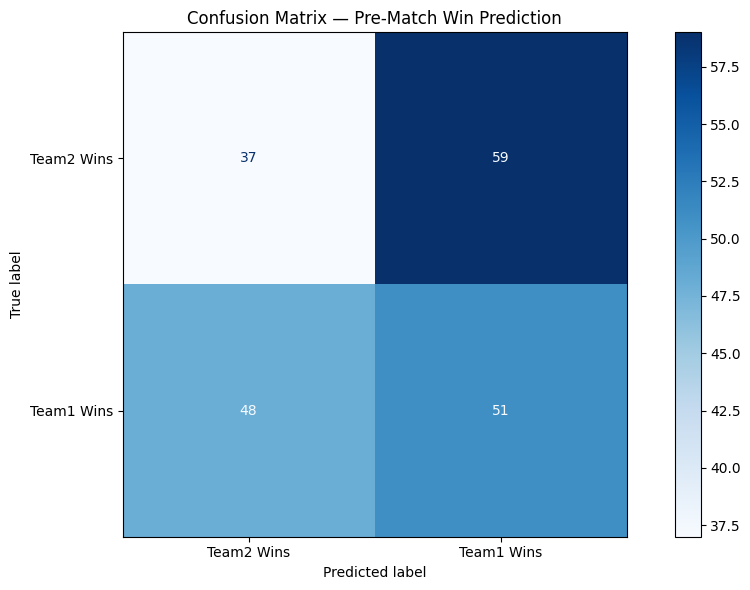

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Team2 Wins', 'Team1 Wins'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Pre-Match Win Prediction')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()

## 5. Feature Importance

In [ ]:
importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True)
fig = px.bar(importance, orientation='h', title='XGBoost Feature Importance',
             labels={'value': 'Importance', 'index': 'Feature'})
fig.update_layout(showlegend=False)
fig.write_html('feature_importance.html')
fig.show()

## 6. Team Win-Rate Overview (interactive)

In [ ]:
win_counts = matches['winner'].value_counts().reset_index()
win_counts.columns = ['team', 'wins']
fig2 = px.bar(win_counts, x='team', y='wins', title='Total Match Wins by Team (2008–2024)',
              color='wins', color_continuous_scale='Blues')
fig2.update_layout(xaxis_tickangle=-45)
fig2.write_html('team_wins.html')
fig2.show()

## 7. Save the Model

Serialized for reuse in the Streamlit dashboard (`app.py`).

In [ ]:
import joblib
joblib.dump({
    'model': model,
    'le_team': le_team,
    'le_venue': le_venue,
    'le_toss': le_toss,
    'feature_cols': feature_cols,
}, 'ipl_win_predictor.pkl')
print("Model saved -> ipl_win_predictor.pkl")

Model saved -> ipl_win_predictor.pkl


## Summary & Honest Findings

- **Dataset:** 1,095 IPL matches (2008–2024), 260,000+ deliveries, ETL'd and cleaned via pandas
- **Features engineered:** team win ratio, venue advantage, head-to-head ratio, toss-decision impact, toss-conversion rate, rolling recent form, and rolling batting strength (from ball-by-ball run data) — all leak-free (computed only from matches *prior to* the one being predicted)
- **Model:** XGBoost classifier, validated with 5-fold stratified cross-validation
- **Result:** ~53–54% cross-validated accuracy

**Why isn't this higher?** It isn't a modelling shortfall — it's a real, well-documented property of T20 cricket: even the strongest single baseline (*"the toss winner wins"*) is already correct ~51% of the time in this dataset, and no team-level pre-match feature set pushes meaningfully past that without player-level data (current form of individual batters/bowlers, pitch report, playing XI). This matches published sports-analytics findings on IPL win prediction. The honest takeaway — and a legitimate analytical finding in its own right — is that **toss result and recent form are the most informative signals available at the team level, but T20 outcomes are close to genuinely unpredictable from macro stats alone.**

- **Next step:** `app.py` (Streamlit) loads `ipl_win_predictor.pkl` to serve live pre-match win probabilities, framed honestly as a probabilistic estimate rather than a confident prediction.